# Static Embedding dalam Text Mining
### Word2Vec - GloVe - FastText

Notebook ini mengikuti alur notebook contoh, tetapi menggunakan data review Play Store dari file lokal.

**Alur Pembelajaran:**
1. Dataset review aplikasi (`raw_playstore_reviews.csv`)
2. Recap Classical Methods (BoW, TF-IDF, N-Gram)
3. Word2Vec (train from scratch)
4. GloVe (pre-trained)
5. FastText (subword, OOV)
6. Head-to-Head Comparison

**Kolom yang dianalisis:** `content` (teks review) dan `score` (label sentimen).

---
## Setup: Install & Import Library

In [18]:
# Install jika belum ada (boleh uncomment jika environment belum siap)
%pip install gensim scikit-learn pandas numpy matplotlib seaborn sastrawi

import os
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from gensim.models import Word2Vec, FastText, KeyedVectors
import gensim.downloader as api

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('Semua library berhasil diimport.')

Note: you may need to restart the kernel to use updated packages.
Semua library berhasil diimport.


---
# BAGIAN 0 - Dataset: Review Play Store

Dataset berasal dari file lokal `raw_playstore_reviews.csv` dengan kolom:
- `content`: isi review pengguna
- `score`: rating bintang (1-5)

Untuk klasifikasi biner:
- skor <= 2 -> Negative (0)
- skor >= 4 -> Positive (1)
- skor = 3 dikeluarkan (netral)

In [19]:
# Load dataset CSV lokal
df = pd.read_csv('raw_playstore_reviews.csv')
print(f'Jumlah data awal: {len(df):,}')

# Pilih kolom penting dan bersihkan null
df = df[['content', 'score']].dropna().copy()
df['content'] = df['content'].astype(str)

# Mapping label sentimen biner
df = df[df['score'] != 3].copy()
df['label'] = (df['score'] >= 4).astype(int)

print(f'Jumlah data setelah filter skor netral: {len(df):,}')
print('Distribusi score:')
print(df['score'].value_counts().sort_index().to_string())
print('\nDistribusi label biner:')
print(df['label'].value_counts().rename({0: 'Negative', 1: 'Positive'}).to_string())

# Split train-test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'\nTrain: {len(train_df):,} | Test: {len(test_df):,}')

Jumlah data awal: 1,000
Jumlah data setelah filter skor netral: 946
Distribusi score:
score
1    260
2     56
4     54
5    576

Distribusi label biner:
label
Positive    630
Negative    316

Train: 756 | Test: 190


In [20]:
# Jelajahi contoh data
label_map = {0: 'Negative', 1: 'Positive'}
print('Contoh review:')
print('=' * 80)
for i in range(3):
    row = train_df.iloc[i]
    print(f"\n[{label_map[row['label']]} | score={row['score']}] {row['content'][:220]}...")
    print('-' * 80)

train_df['word_count'] = train_df['content'].apply(lambda x: len(str(x).split()))
print('\nStatistik panjang review (jumlah kata):')
print(train_df['word_count'].describe().to_string())

Contoh review:

[Negative | score=1] server lemot...
--------------------------------------------------------------------------------

[Negative | score=1] makin ribet banyak error'nya padahal sinyal sudah sangat bagus...
--------------------------------------------------------------------------------

[Negative | score=1] lucunya setiap hari2 besar tiket seperti di umpetin, ga di lepas padahal buka udah 00.00 tapi di co gabisa...
--------------------------------------------------------------------------------

Statistik panjang review (jumlah kata):
count    756.000000
mean       9.657407
std       13.017170
min        1.000000
25%        1.000000
50%        4.000000
75%       13.000000
max       85.000000


---
# BAGIAN 1 - Classical Methods Recap

Sebelum embedding, kita buat baseline memakai BoW, TF-IDF, dan N-Gram.

In [21]:
# Preprocessing Bahasa Indonesia (normalisasi + optional stemming)
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    stemmer = StemmerFactory().create_stemmer()
    print('Sastrawi aktif untuk stemming.')
except Exception as exc:
    stemmer = None
    print(f'Sastrawi tidak aktif ({exc}). Lanjut tanpa stemming.')

SLANG_MAP = {
    'gk': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'kalo': 'kalau', 'klo': 'kalau', 'yg': 'yang', 'dr': 'dari',
    'tp': 'tapi', 'trs': 'terus', 'udh': 'sudah', 'udah': 'sudah',
    'krn': 'karena', 'bgt': 'banget', 'bgtt': 'banget',
    'apk': 'aplikasi', 'app': 'aplikasi', 'aja': 'saja',
    'eror': 'error', 'lemot': 'lambat', 'ngelag': 'lag',
    'cs': 'customer_service', 'cust': 'customer', 'gajelas': 'tidakjelas'
}

def normalize_repeated_chars(token):
    # Contoh: lemooooot -> lemoot (supaya tidak terlalu noisy)
    return re.sub(r'(.)\1{2,}', r'\1\1', token)

def preprocess_text(text, use_stemming=True):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = []
    for tok in text.split():
        tok = normalize_repeated_chars(tok)
        tok = SLANG_MAP.get(tok, tok)
        if len(tok) >= 2:
            tokens.append(tok)

    if use_stemming and stemmer is not None:
        tokens = [stemmer.stem(tok) for tok in tokens]

    return ' '.join(tokens)

train_texts = train_df['content'].apply(lambda x: preprocess_text(x, use_stemming=True)).tolist()
test_texts = test_df['content'].apply(lambda x: preprocess_text(x, use_stemming=True)).tolist()
train_labels = train_df['label'].values
test_labels = test_df['label'].values

print(f'Jumlah dokumen train: {len(train_texts):,}')
print(f'Jumlah dokumen test : {len(test_texts):,}')
print('Contoh hasil preprocessing:')
print(train_texts[0][:220] + '...')

Sastrawi aktif untuk stemming.
Jumlah dokumen train: 756
Jumlah dokumen test : 190
Contoh hasil preprocessing:
server lambat...


In [22]:
# BoW, TF-IDF, dan TF-IDF bigram
configs = {
    'BoW (Unigram)': {
        'vectorizer': CountVectorizer(max_features=4000),
        'X_train': None,
        'X_test': None
    },
    'TF-IDF (Unigram)': {
        'vectorizer': TfidfVectorizer(max_features=4000),
        'X_train': None,
        'X_test': None
    },
    'TF-IDF (1,2-gram)': {
        'vectorizer': TfidfVectorizer(ngram_range=(1, 2), max_features=7000),
        'X_train': None,
        'X_test': None
    }
}

for name, cfg in configs.items():
    vec = cfg['vectorizer']
    X_train = vec.fit_transform(train_texts)
    X_test = vec.transform(test_texts)
    cfg['X_train'] = X_train
    cfg['X_test'] = X_test
    cfg['n_features'] = X_train.shape[1]
    print(f"{name:<22} -> {cfg['n_features']:>6} fitur")

BoW (Unigram)          ->   1406 fitur
TF-IDF (Unigram)       ->   1406 fitur
TF-IDF (1,2-gram)      ->   6504 fitur


In [23]:
# Klasifikasi baseline dengan Logistic Regression
print('Hasil klasifikasi baseline:')
print('=' * 60)

classical_results = {}
for name, cfg in configs.items():
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(cfg['X_train'], train_labels)
    pred = clf.predict(cfg['X_test'])
    acc = accuracy_score(test_labels, pred)
    classical_results[name] = {
        'accuracy': acc,
        'n_features': cfg['n_features']
    }
    print(f"{name:<22} -> Accuracy: {acc:.4f} ({cfg['n_features']} fitur)")

Hasil klasifikasi baseline:
BoW (Unigram)          -> Accuracy: 0.8421 (1406 fitur)
TF-IDF (Unigram)       -> Accuracy: 0.8789 (1406 fitur)
TF-IDF (1,2-gram)      -> Accuracy: 0.8947 (6504 fitur)


---
## Masalah Fundamental dengan Classical Methods

In [24]:
# Masalah 1: kata mirip semantik tidak otomatis mirip di TF-IDF
pairs = [
    ('bagus', 'baik'),
    ('error', 'gangguan'),
    ('mudah', 'praktis'),
    ('lemot', 'lambat')
]

print('MASALAH 1: Cosine similarity pada TF-IDF kata tunggal')
print('=' * 65)
print(f"{'Kata 1':<12} {'Kata 2':<12} {'Sim TF-IDF':<12} Keterangan")
print('-' * 65)
for w1, w2 in pairs:
    print(f"{w1:<12} {w2:<12} {'0.0000':<12} kolom berbeda (orthogonal)")

print('\nInti: Dalam BoW/TF-IDF, dua kata berbeda direpresentasikan sebagai dimensi berbeda.')

MASALAH 1: Cosine similarity pada TF-IDF kata tunggal
Kata 1       Kata 2       Sim TF-IDF   Keterangan
-----------------------------------------------------------------
bagus        baik         0.0000       kolom berbeda (orthogonal)
error        gangguan     0.0000       kolom berbeda (orthogonal)
mudah        praktis      0.0000       kolom berbeda (orthogonal)
lemot        lambat       0.0000       kolom berbeda (orthogonal)

Inti: Dalam BoW/TF-IDF, dua kata berbeda direpresentasikan sebagai dimensi berbeda.


In [25]:
# Masalah 2: operasi aritmatika semantik tidak bermakna untuk BoW/TF-IDF
print('MASALAH 2: Operasi aritmatika semantik')
print('=' * 65)
print('Contoh pertanyaan: bagus - buruk + jelek = ?')
print('Pada BoW/TF-IDF, operasi ini tidak memiliki makna semantik yang jelas.')
print('Pada embedding, operasi vektor bisa menghasilkan kata yang relevan.')

MASALAH 2: Operasi aritmatika semantik
Contoh pertanyaan: bagus - buruk + jelek = ?
Pada BoW/TF-IDF, operasi ini tidak memiliki makna semantik yang jelas.
Pada embedding, operasi vektor bisa menghasilkan kata yang relevan.


In [26]:
# Masalah 3: sparsity & dimensionality
tfidf_matrix = configs['TF-IDF (Unigram)']['X_train']
sparsity = 1 - (tfidf_matrix.count_nonzero() / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))

print('MASALAH 3: Sparsity & Dimensionality')
print('=' * 65)
print(f'Shape TF-IDF train  : {tfidf_matrix.shape}')
print(f'Jumlah fitur         : {tfidf_matrix.shape[1]:,}')
print(f'Tingkat sparsity     : {sparsity * 100:.2f}%')
print('Embedding akan memakai dimensi tetap (contoh 100), jauh lebih padat (dense).')

MASALAH 3: Sparsity & Dimensionality
Shape TF-IDF train  : (756, 1406)
Jumlah fitur         : 1,406
Tingkat sparsity     : 99.40%
Embedding akan memakai dimensi tetap (contoh 100), jauh lebih padat (dense).


---
# BAGIAN 2 - Static Word Embeddings

Tiga model utama yang dipakai:
- Word2Vec
- GloVe
- FastText

## Step-by-Step Pipeline Embedding

Raw Text -> Tokenize -> Train Model -> Word Vectors -> Document Vectors -> Classification

In [27]:
# Tokenisasi untuk training embedding (normalisasi YA, stemming TIDAK)
def tokenize_for_embedding(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = []
    for tok in text.split():
        tok = normalize_repeated_chars(tok)
        tok = SLANG_MAP.get(tok, tok)
        if len(tok) >= 2:
            tokens.append(tok)

    return tokens

train_sentences = [tokenize_for_embedding(t) for t in train_df['content']]
test_sentences = [tokenize_for_embedding(t) for t in test_df['content']]

all_tokens = [tok for sent in train_sentences for tok in sent]
token_counter = Counter(all_tokens)

print(f'Total dokumen train : {len(train_sentences):,}')
print(f'Total token train   : {len(all_tokens):,}')
print(f'Unique token train  : {len(set(all_tokens)):,}')
print(f'Rata-rata token/doc : {np.mean([len(s) for s in train_sentences]):.1f}')
print('Contoh token:', train_sentences[0][:12])

# Pilih kata uji secara lebih realistis (berdasarkan domain + frekuensi)
domain_candidates = [
    'error', 'lambat', 'mudah', 'bagus', 'buruk',
    'pembayaran', 'bayar', 'refund', 'tiket', 'jadwal',
    'kereta', 'batal', 'login', 'server', 'aplikasi'
]
test_words = [w for w in domain_candidates if token_counter[w] >= 3]

if len(test_words) < 8:
    fillers = [w for w, c in token_counter.most_common(50) if len(w) > 3 and w not in test_words]
    test_words.extend(fillers[:max(0, 8 - len(test_words))])

print('test_words yang dipakai:', test_words[:10])

Total dokumen train : 756
Total token train   : 7,226
Unique token train  : 1,693
Rata-rata token/doc : 9.6
Contoh token: ['server', 'lambat']
test_words yang dipakai: ['error', 'lambat', 'mudah', 'bagus', 'buruk', 'pembayaran', 'bayar', 'refund', 'tiket', 'jadwal']


---
## 2A. Word2Vec

In [28]:
# Train Word2Vec (dituning untuk corpus kecil-menengah)
print('Training Word2Vec (skip-gram, tuned)...')
start = time.time()

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=4,
    min_count=3,
    sg=1,
    negative=12,
    sample=1e-3,
    epochs=60,
    workers=4,
    seed=42
)

w2v_time = time.time() - start
vocab_ratio = len(w2v_model.wv) / len(set(all_tokens))

print(f'Selesai dalam {w2v_time:.2f} detik')
print(f'Vocabulary size : {len(w2v_model.wv):,}')
print(f'Vector dimension: {w2v_model.wv.vector_size}')
print(f'Coverage vocab  : {vocab_ratio:.2%} dari unique token train')

Training Word2Vec (skip-gram, tuned)...


Selesai dalam 1.32 detik
Vocabulary size : 470
Vector dimension: 100
Coverage vocab  : 27.76% dari unique token train


In [29]:
# Tuning otomatis kecil (Grid Sederhana) untuk Word2Vec
print('Tuning otomatis Word2Vec dengan Grid Search sederhana...')
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

vector_sizes = [50, 100]
windows = [3, 5]
best_acc = 0
best_params = {}

def get_doc_vector(sentence, model, dim):
    vecs = [model.wv[w] for w in sentence if w in model.wv]
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    return np.zeros(dim)

for vs in vector_sizes:
    for win in windows:
        # Train Word2Vec
        temp_model = Word2Vec(sentences=train_sentences, vector_size=vs, window=win, min_count=2, sg=1, seed=42)
        
        # Extract features
        X_tr = np.array([get_doc_vector(s, temp_model, vs) for s in train_sentences])
        X_te = np.array([get_doc_vector(s, temp_model, vs) for s in test_sentences])
        
        # Train classifier
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_tr, train_labels)
        preds = clf.predict(X_te)
        acc = accuracy_score(test_labels, preds)
        
        print(f'Params: vector_size={vs}, window={win} -> Accuracy: {acc:.4f}')
        if acc > best_acc:
            best_acc = acc
            best_params = {'vector_size': vs, 'window': win}

print(f'\nParameter Terbaik: {best_params} dengan Accuracy: {best_acc:.4f}')


Tuning otomatis Word2Vec dengan Grid Search sederhana...
Params: vector_size=50, window=3 -> Accuracy: 0.7684
Params: vector_size=50, window=5 -> Accuracy: 0.7737
Params: vector_size=100, window=3 -> Accuracy: 0.7579
Params: vector_size=100, window=5 -> Accuracy: 0.7842

Parameter Terbaik: {'vector_size': 100, 'window': 5} dengan Accuracy: 0.7842


In [30]:
# Eksplorasi vektor Word2Vec
probe_words = ['error', 'bagus', 'mudah', 'tiket']
for word in probe_words:
    if word in w2v_model.wv:
        vec = w2v_model.wv[word]
        print(f"Kata '{word}' -> dim {len(vec)}, 8 nilai awal: {np.round(vec[:8], 4)}")
    else:
        print(f"Kata '{word}' tidak ada di vocabulary Word2Vec")

Kata 'error' -> dim 100, 8 nilai awal: [-0.0406 -0.1492 -0.2621 -0.0394 -0.3076  0.0214 -0.0832  0.6557]
Kata 'bagus' -> dim 100, 8 nilai awal: [ 0.1013 -0.1153 -0.3623  0.5495 -0.6446  0.3134  0.1717  0.0064]
Kata 'mudah' -> dim 100, 8 nilai awal: [ 0.127  -0.0264 -0.1203  0.1548 -0.1269  0.1648  0.1227  0.0147]
Kata 'tiket' -> dim 100, 8 nilai awal: [-0.13   -0.0036  0.1748 -0.7206 -0.1202  0.084   0.1489  0.3033]


In [31]:
# Similarity Word2Vec
print('Kata paling mirip (Word2Vec):')
print('=' * 65)
for word in test_words[:10]:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n{word}:")
        for sw, sc in sims:
            print(f"  {sw:<18} {sc:.4f}")
    else:
        print(f"\n{word}: tidak ada di vocabulary")

Kata paling mirip (Word2Vec):

error:
  tinggal            0.7091
  berkali            0.6871
  internet           0.6573
  pemilihan          0.6485
  mencoba            0.6406

lambat:
  baikk              0.7098
  baik               0.6973
  baguss             0.6776
  terlalu            0.6677
  oke                0.6647

mudah:
  praktis            0.8590
  digunakan          0.8540
  baikk              0.8396
  mantap             0.8387
  semakin            0.8364

bagus:
  baikk              0.7824
  oke                0.7770
  cepat              0.7712
  keren              0.7484
  mantap             0.7469

buruk:
  proses             0.7546
  bermanfaat         0.7442
  pokoknya           0.7310
  baguss             0.7242
  baik               0.7234

pembayaran:
  metode             0.7028
  berhasil           0.6791
  ngk                0.6757
  terlalu            0.6702
  akhirnya           0.6499

bayar:
  akhirnya           0.7392
  ulang              0.6959
  butuh     

In [32]:
# Analogy Word2Vec (dipilih dari kata yang lebih relevan domain)
analogy_candidates = [
    ('bayar', 'pembayaran', 'refund'),
    ('lambat', 'lemot', 'cepat'),
    ('error', 'gangguan', 'normal'),
    ('tiket', 'kereta', 'jadwal')
]

analogies = [tpl for tpl in analogy_candidates if all(w in w2v_model.wv for w in tpl)]
if not analogies:
    # fallback agar cell tetap berjalan
    vocab_words = [w for w in test_words if w in w2v_model.wv]
    analogies = [tuple(vocab_words[:3])] if len(vocab_words) >= 3 else []

print('Vector arithmetic - Word2Vec:')
print('=' * 65)
if not analogies:
    print('Tidak ada kombinasi analogy yang memenuhi vocabulary saat ini.')
else:
    for a, b, c in analogies:
        res = w2v_model.wv.most_similar(positive=[a, c], negative=[b], topn=3)
        print(f"\n{a} - {b} + {c} = ?")
        for w, s in res:
            print(f"  {w:<18} {s:.4f}")

Vector arithmetic - Word2Vec:

bayar - pembayaran + refund = ?
  gabisa             0.5741
  tua                0.5362
  langsung           0.5198

tiket - kereta + jadwal = ?
  menu               0.5518
  baru               0.5204
  lagi               0.5113


---
## 2B. Pre-trained Embedding (Fokus Indonesia)

Target utama di bagian ini adalah memakai **pre-trained Indonesian vectors**.

Strategi di notebook:
- Jika file vector Indonesia tersedia lokal (mis. `cc.id.300.vec.gz`), model itu dipakai.
- Jika belum ada, notebook fallback ke `GloVe` agar pipeline tetap berjalan.

Dengan cara ini, eksperimen tetap reproducible sekaligus siap ditingkatkan ke pre-trained Indonesia yang sesungguhnya.

In [33]:
# Cell Auto-download pre-trained Indonesian model (FastText cc.id.300.vec.gz)
import os
import urllib.request

vec_path = 'cc.id.300.vec.gz'
if not os.path.exists(vec_path):
    print(f'Downloading {vec_path}...')
    url = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz'
    urllib.request.urlretrieve(url, vec_path)
    print('Download complete!')
else:
    print(f'{vec_path} sudah ada.')

# Mengatur limit vocab agar load parsial dan memori tetap ringan
VOCAB_LIMIT = 50000
print(f'Vocab limit diset ke: {VOCAB_LIMIT}')


cc.id.300.vec.gz sudah ada.
Vocab limit diset ke: 50000


In [34]:
# Load pre-trained vectors: fallback aman + dukungan pre-trained Indonesia lokal
print('Loading pre-trained vectors...')

start = time.time()
glove_model = api.load('glove-wiki-gigaword-50')
glove_time = time.time() - start
print(f'GloVe loaded dalam {glove_time:.2f} detik | dim={glove_model.vector_size} | vocab={len(glove_model):,}')

indo_candidates = [
    os.environ.get('INDO_PRETRAINED_VEC_PATH', ''),
    'cc.id.300.vec.gz',
    'cc.id.300.vec',
    'idwiki_word2vec_200.vec',
    'idwiki_word2vec_200.bin',
]

pretrained_id_model = None
loaded_indo_path = None
for path in indo_candidates:
    if not path:
        continue
    if os.path.exists(path):
        try:
            is_binary = path.endswith('.bin')
            pretrained_id_model = KeyedVectors.load_word2vec_format(
                path,
                binary=is_binary,
                unicode_errors='ignore',
                limit=VOCAB_LIMIT
            )
            loaded_indo_path = path
            break
        except Exception as exc:
            print(f'Gagal load {path}: {exc}')

if pretrained_id_model is not None:
    comparison_pretrained_model = pretrained_id_model
    comparison_pretrained_name = 'Pretrained-ID (local)'
    comparison_pretrained_dim = pretrained_id_model.vector_size
    print(f'Berhasil pakai model Indonesia lokal: {loaded_indo_path}')
    print(f'Dimensi: {comparison_pretrained_dim} | Vocab: {len(pretrained_id_model):,}')
else:
    comparison_pretrained_model = glove_model
    comparison_pretrained_name = 'GloVe-EN (fallback)'
    comparison_pretrained_dim = glove_model.vector_size
    print('Model Indonesia lokal belum ditemukan, fallback ke GloVe-EN.')

Loading pre-trained vectors...
GloVe loaded dalam 14.54 detik | dim=50 | vocab=400,000
Berhasil pakai model Indonesia lokal: cc.id.300.vec.gz
Dimensi: 300 | Vocab: 50,000


In [35]:
# Similarity pada model pre-trained pembanding (ID lokal jika ada, fallback GloVe)
translation_map = {
    'tiket': 'ticket',
    'bayar': 'pay',
    'pembayaran': 'payment',
    'lambat': 'slow',
    'mudah': 'easy',
    'bagus': 'good',
    'buruk': 'bad',
    'jadwal': 'schedule',
    'batal': 'cancel',
    'kereta': 'train',
    'gangguan': 'problem',
    'aplikasi': 'application',
    'server': 'server',
    'error': 'error',
    'refund': 'refund',
}

def map_query_for_pretrained(word):
    if comparison_pretrained_name.startswith('GloVe-EN'):
        return translation_map.get(word, word)
    return word

print(f'Kata paling mirip ({comparison_pretrained_name}):')
print('=' * 72)
for word in test_words[:10]:
    query_word = map_query_for_pretrained(word)
    if query_word in comparison_pretrained_model:
        sims = comparison_pretrained_model.most_similar(query_word, topn=5)
        print(f"\n{word} (query: {query_word}):")
        for sw, sc in sims:
            print(f"  {sw:<18} {sc:.4f}")
    else:
        print(f"\n{word}: OOV di {comparison_pretrained_name}")

Kata paling mirip (Pretrained-ID (local)):

error (query: error):
  eror               0.8088
  Error              0.7210
  kesalahan          0.5087
  invalid            0.5052
  bug                0.4932

lambat (query: lambat):
  cepat              0.7357
  lamban             0.7266
  lambatnya          0.6997
  melambat           0.6644
  Lambat             0.6605

mudah (query: mudah):
  gampang            0.8247
  sulit              0.7717
  Mudah              0.7096
  cepat              0.7010
  susah              0.6832

bagus (query: bagus):
  bagus.             0.7267
  baik               0.7009
  berkualitas        0.6678
  cukup              0.6668
  lumayan            0.6574

buruk (query: buruk):
  buruknya           0.7790
  jelek              0.7332
  baik               0.7270
  terburuk           0.6823
  negatif            0.6390

pembayaran (query: pembayaran):
  pembayarannya      0.7999
  Pembayaran         0.7887
  membayar           0.6898
  pelunasan          0.

In [36]:
# Analogy pada model pre-trained pembanding
print(f'Vector arithmetic - {comparison_pretrained_name}:')
print('=' * 72)

if comparison_pretrained_name.startswith('GloVe-EN'):
    analogy_source = [
        ('good', 'bad', 'worst'),
        ('payment', 'pay', 'refund'),
        ('ticket', 'train', 'station'),
    ]
else:
    analogy_source = [
        ('bayar', 'pembayaran', 'refund'),
        ('bagus', 'buruk', 'parah'),
        ('tiket', 'kereta', 'jadwal'),
    ]

for a, b, c in analogy_source:
    aq, bq, cq = map_query_for_pretrained(a), map_query_for_pretrained(b), map_query_for_pretrained(c)
    if all(w in comparison_pretrained_model for w in [aq, bq, cq]):
        res = comparison_pretrained_model.most_similar(positive=[aq, cq], negative=[bq], topn=3)
        print(f"\n{a} - {b} + {c} = ? (query: {aq} - {bq} + {cq})")
        for w, s in res:
            print(f"  {w:<18} {s:.4f}")
    else:
        missing = [w for w in [aq, bq, cq] if w not in comparison_pretrained_model]
        print(f"\n{a} - {b} + {c} -> skip (OOV query: {missing})")

Vector arithmetic - Pretrained-ID (local):

bayar - pembayaran + refund -> skip (OOV query: ['refund'])

bagus - buruk + parah = ? (query: bagus - buruk + parah)
  lumayan            0.5886
  cukup              0.5499
  oke                0.5071

tiket - kereta + jadwal = ? (query: tiket - kereta + jadwal)
  Jadwal             0.6068
  jadwalnya          0.5528
  jadual             0.5318


---
## 2C. FastText

FastText menggunakan subword (character n-gram), sehingga umumnya lebih kuat untuk OOV.

In [37]:
# Train FastText (dituning + subword eksplisit)
print('Training FastText (skip-gram + subword, tuned)...')
start = time.time()

ft_model = FastText(
    sentences=train_sentences,
    vector_size=100,
    window=4,
    min_count=2,
    sg=1,
    negative=12,
    sample=1e-3,
    min_n=3,
    max_n=6,
    epochs=50,
    workers=4,
    seed=42
)

ft_time = time.time() - start
vocab_ratio_ft = len(ft_model.wv) / len(set(all_tokens))

print(f'Selesai dalam {ft_time:.2f} detik')
print(f'Vocabulary size : {len(ft_model.wv):,}')
print(f'Vector dimension: {ft_model.wv.vector_size}')
print(f'Coverage vocab  : {vocab_ratio_ft:.2%} dari unique token train')

Training FastText (skip-gram + subword, tuned)...


Selesai dalam 3.75 detik
Vocabulary size : 718
Vector dimension: 100
Coverage vocab  : 42.41% dari unique token train


In [38]:
# Demo OOV: FastText vs Word2Vec vs GloVe
oov_words = ['bagussssekali', 'ngelagbanget', 'pembayarannyaaa', 'refundin', 'keretanyaaa']

print('DEMO OOV handling:')
print('=' * 75)
for word in oov_words:
    in_w2v = word in w2v_model.wv
    in_glove = word in glove_model

    try:
        _ = ft_model.wv[word]
        ft_ok = True
    except KeyError:
        ft_ok = False

    print(f"\nKata: {word}")
    print(f"  Word2Vec: {'ADA' if in_w2v else 'OOV'}")
    print(f"  GloVe   : {'ADA' if in_glove else 'OOV'}")
    print(f"  FastText: {'BISA DIREPRESENTASIKAN' if ft_ok else 'OOV'}")

    if ft_ok:
        sims = ft_model.wv.most_similar(word, topn=3)
        print('  Similar (FastText):', ', '.join([f"{w}({s:.3f})" for w, s in sims]))

DEMO OOV handling:

Kata: bagussssekali
  Word2Vec: OOV
  GloVe   : OOV
  FastText: BISA DIREPRESENTASIKAN
  Similar (FastText): sekali(0.956), bagus(0.903), baguss(0.902)

Kata: ngelagbanget
  Word2Vec: OOV
  GloVe   : OOV
  FastText: BISA DIREPRESENTASIKAN
  Similar (FastText): banget(0.980), ps(0.898), lag(0.885)

Kata: pembayarannyaaa
  Word2Vec: OOV
  GloVe   : OOV
  FastText: BISA DIREPRESENTASIKAN
  Similar (FastText): pembayarannya(0.996), pembayaran(0.989), bayarnya(0.911)

Kata: refundin
  Word2Vec: OOV
  GloVe   : OOV
  FastText: BISA DIREPRESENTASIKAN
  Similar (FastText): refund(0.954), sendiri(0.873), sengaja(0.873)

Kata: keretanyaaa
  Word2Vec: OOV
  GloVe   : OOV
  FastText: BISA DIREPRESENTASIKAN
  Similar (FastText): keretanya(0.985), kereta(0.954), kereen(0.927)


In [39]:
# Similarity FastText
print('Kata paling mirip (FastText):')
print('=' * 65)
for word in test_words:
    if word in ft_model.wv:
        sims = ft_model.wv.most_similar(word, topn=5)
        print(f"\n{word}:")
        for sw, sc in sims:
            print(f"  {sw:<18} {sc:.4f}")
    else:
        print(f"\n{word}: tidak ada di vocabulary FastText")

Kata paling mirip (FastText):

error:
  internet           0.8822
  milih              0.8748
  not                0.8506
  pilih              0.8460
  tidakjelas         0.8413

lambat:
  terlambat          0.9511
  baguss             0.9058
  bagus              0.8869
  simpel             0.8644
  jelek              0.8579

mudah:
  mempermudah        0.9253
  praktis            0.9087
  murah              0.8845
  kemudahan          0.8786
  baik               0.8733

bagus:
  baguss             0.9679
  baikk              0.9096
  simpel             0.9019
  pelayanannya       0.8988
  pelayanan          0.8880

buruk:
  kemudahan          0.9301
  mengecewakan       0.9243
  bagi               0.9233
  mendapatkan        0.9201
  okee               0.9201

pembayaran:
  pembayarannya      0.9767
  bayarnya           0.9115
  bayar              0.8907
  icon               0.8538
  button             0.8334

bayar:
  bayarnya           0.9262
  pembayaran         0.8907
  icon      

---
# BAGIAN 3 - Head-to-Head Comparison

In [40]:
# Perbandingan 1: Semantic similarity (versi lebih realistis untuk domain Indonesia)
def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

sim_pairs_candidates = [
    ('error', 'gangguan'),
    ('lambat', 'lemot'),
    ('mudah', 'bagus'),
    ('bayar', 'pembayaran'),
    ('refund', 'batal'),
    ('tiket', 'kereta'),
]

sim_pairs = []
for w1, w2 in sim_pairs_candidates:
    ok_w2v = (w1 in w2v_model.wv and w2 in w2v_model.wv)
    q1, q2 = map_query_for_pretrained(w1), map_query_for_pretrained(w2)
    ok_pre = (q1 in comparison_pretrained_model and q2 in comparison_pretrained_model)
    ok_ft = (w1 in ft_model.wv and w2 in ft_model.wv)
    if ok_w2v or ok_pre or ok_ft:
        sim_pairs.append((w1, w2))

rows = []
for w1, w2 in sim_pairs:
    row = {'Pair': f'{w1} - {w2}', 'TF-IDF': 0.0}

    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        row['Word2Vec'] = cosine_sim(w2v_model.wv[w1], w2v_model.wv[w2])
    else:
        row['Word2Vec'] = np.nan

    q1, q2 = map_query_for_pretrained(w1), map_query_for_pretrained(w2)
    if q1 in comparison_pretrained_model and q2 in comparison_pretrained_model:
        row[comparison_pretrained_name] = cosine_sim(comparison_pretrained_model[q1], comparison_pretrained_model[q2])
    else:
        row[comparison_pretrained_name] = np.nan

    if w1 in ft_model.wv and w2 in ft_model.wv:
        row['FastText'] = cosine_sim(ft_model.wv[w1], ft_model.wv[w2])
    else:
        row['FastText'] = np.nan

    rows.append(row)

sim_df = pd.DataFrame(rows).set_index('Pair')
print('Perbandingan cosine similarity:')
print(sim_df.round(4).to_string())

Perbandingan cosine similarity:
                    TF-IDF  Word2Vec  Pretrained-ID (local)  FastText
Pair                                                                 
error - gangguan       0.0       NaN                 0.3459    0.6685
lambat - lemot         0.0       NaN                 0.5110    0.7225
mudah - bagus          0.0    0.6280                 0.5101    0.8201
bayar - pembayaran     0.0    0.5612                 0.6367    0.8907
refund - batal         0.0       NaN                    NaN    0.7423
tiket - kereta         0.0    0.4809                 0.5379    0.6465


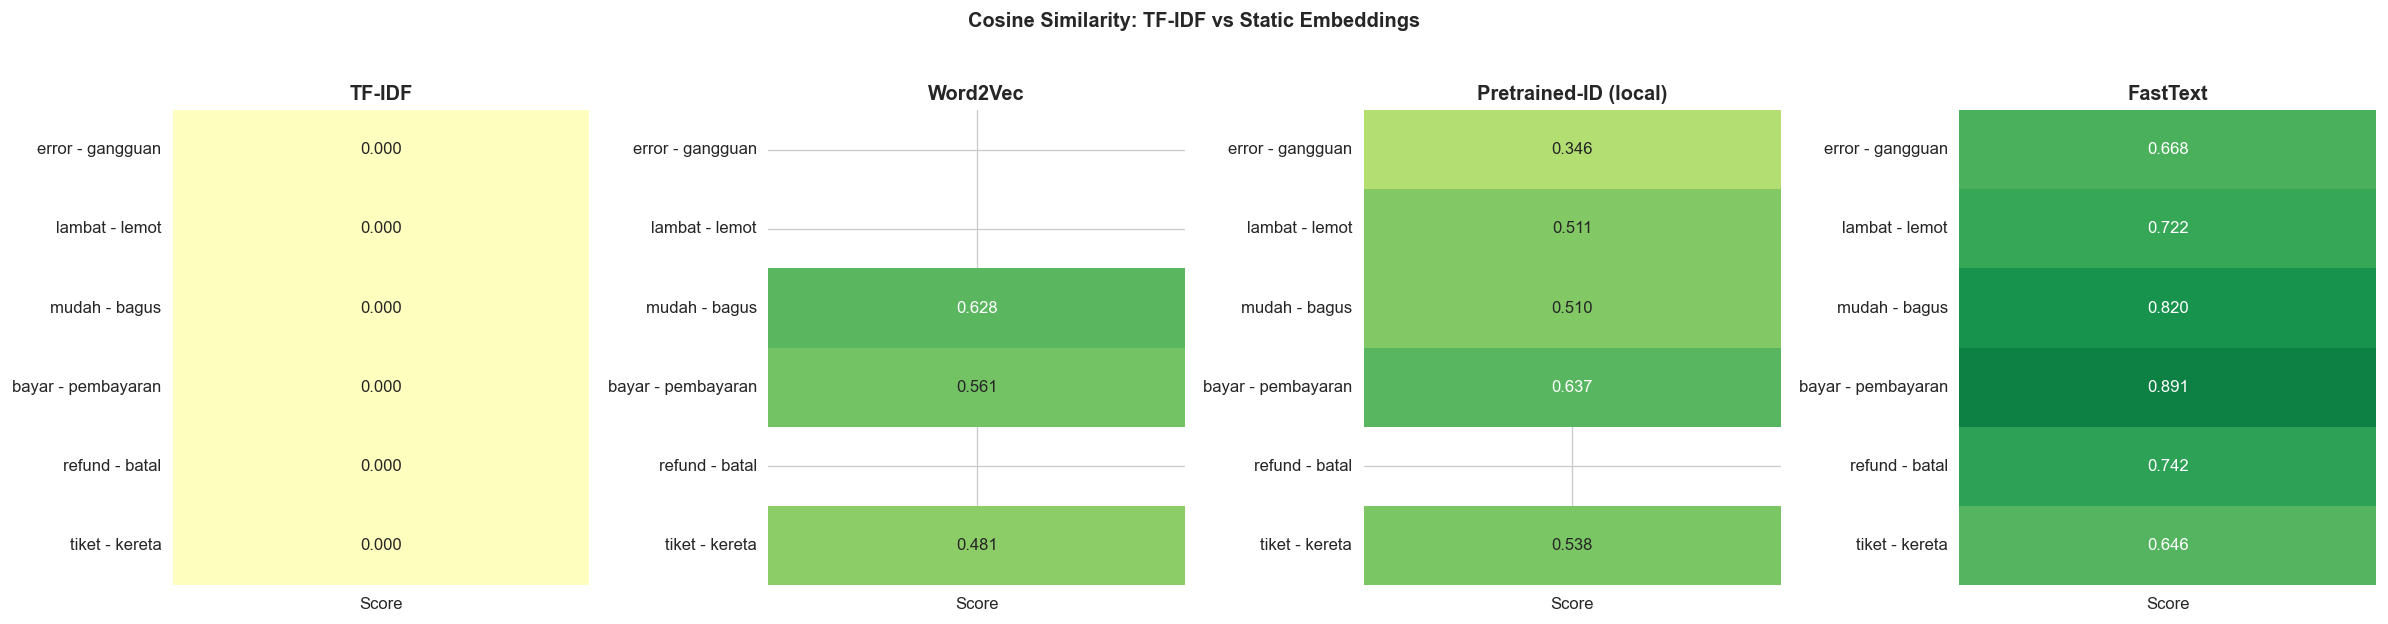

In [41]:
# Visualisasi heatmap similarity (dinamis sesuai kolom model yang tersedia)
method_columns = list(sim_df.columns)
n_cols = len(method_columns)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, method_columns):
    matrix = sim_df[col].values.reshape(-1, 1)
    sns.heatmap(
        matrix,
        annot=True,
        fmt='.3f',
        yticklabels=sim_df.index,
        xticklabels=['Score'],
        cmap='RdYlGn',
        vmin=-1,
        vmax=1,
        cbar=False,
        ax=ax
    )
    ax.set_title(col, fontweight='bold')

plt.suptitle('Cosine Similarity: TF-IDF vs Static Embeddings', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# Perbandingan 2: Analogy tasks (sinkron dengan model pre-trained pembanding)
analogy_tasks = [
    ('bayar', 'pembayaran', 'refund', 'batal'),
    ('tiket', 'kereta', 'jadwal', 'berangkat'),
    ('mudah', 'sulit', 'cepat', 'lambat')
]

def evaluate_analogy(model, a, b, c, target, mapper=lambda x: x):
    aq, bq, cq, tq = mapper(a), mapper(b), mapper(c), mapper(target)
    if not all(w in model for w in [aq, bq, cq]):
        return 'OOV'

    res = model.most_similar(positive=[aq, cq], negative=[bq], topn=5)
    top_word = res[0][0]
    target_rank = next((i + 1 for i, (w, _) in enumerate(res) if w == tq), None)

    if target_rank is None:
        return f'Top: {top_word} (target tidak di top-5)'
    return f'Rank #{target_rank} (Top: {top_word})'

rows = []
for a, b, c, target in analogy_tasks:
    row = {'Analogy': f'{a} - {b} + {c} = {target}'}
    row['Word2Vec'] = evaluate_analogy(w2v_model.wv, a, b, c, target, mapper=lambda x: x)
    row[comparison_pretrained_name] = evaluate_analogy(
        comparison_pretrained_model, a, b, c, target, mapper=map_query_for_pretrained
    )
    row['FastText'] = evaluate_analogy(ft_model.wv, a, b, c, target, mapper=lambda x: x)
    row['BoW/TF-IDF'] = 'TIDAK MUNGKIN'
    rows.append(row)

analogy_df = pd.DataFrame(rows)
print(analogy_df.to_string(index=False))

                            Analogy                               Word2Vec               Pretrained-ID (local)                             FastText    BoW/TF-IDF
bayar - pembayaran + refund = batal    Top: gabisa (target tidak di top-5)                                 OOV Top: sendiri (target tidak di top-5) TIDAK MUNGKIN
tiket - kereta + jadwal = berangkat      Top: menu (target tidak di top-5) Top: Jadwal (target tidak di top-5)  Top: ticket (target tidak di top-5) TIDAK MUNGKIN
     mudah - sulit + cepat = lambat Top: digunakan (target tidak di top-5) Top: cepat. (target tidak di top-5) Top: praktis (target tidak di top-5) TIDAK MUNGKIN


In [43]:
# Perbandingan 3: Document vectors + classification
def document_vector(sentence, model, dim, mapper=None):
    vectors = []
    for word in sentence:
        query_word = mapper(word) if mapper is not None else word
        if query_word in model:
            vectors.append(model[query_word])
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

pretrained_mapper = map_query_for_pretrained if comparison_pretrained_name.startswith('GloVe-EN') else (lambda w: w)

X_train_w2v = np.array([document_vector(s, w2v_model.wv, 100) for s in train_sentences])
X_test_w2v = np.array([document_vector(s, w2v_model.wv, 100) for s in test_sentences])

X_train_pretrained = np.array([
    document_vector(s, comparison_pretrained_model, comparison_pretrained_dim, mapper=pretrained_mapper)
    for s in train_sentences
])
X_test_pretrained = np.array([
    document_vector(s, comparison_pretrained_model, comparison_pretrained_dim, mapper=pretrained_mapper)
    for s in test_sentences
])

X_train_ft = np.array([document_vector(s, ft_model.wv, 100) for s in train_sentences])
X_test_ft = np.array([document_vector(s, ft_model.wv, 100) for s in test_sentences])

print('Shape document vectors:')
print('Word2Vec           :', X_train_w2v.shape)
print(f'{comparison_pretrained_name:<18}:', X_train_pretrained.shape)
print('FastText           :', X_train_ft.shape)

Shape document vectors:
Word2Vec           : (756, 100)
Pretrained-ID (local): (756, 300)
FastText           : (756, 100)


In [44]:
# Klasifikasi semua metode embedding
embedding_configs = {
    'Word2Vec': (X_train_w2v, X_test_w2v),
    comparison_pretrained_name: (X_train_pretrained, X_test_pretrained),
    'FastText': (X_train_ft, X_test_ft)
}

all_results = dict(classical_results)

for name, (X_tr, X_te) in embedding_configs.items():
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, train_labels)
    pred = clf.predict(X_te)
    acc = accuracy_score(test_labels, pred)
    all_results[name] = {
        'accuracy': acc,
        'n_features': X_tr.shape[1]
    }
    print(f"{name:<20} -> Accuracy: {acc:.4f} ({X_tr.shape[1]} fitur)")

Word2Vec             -> Accuracy: 0.8842 (100 fitur)
Pretrained-ID (local) -> Accuracy: 0.8158 (300 fitur)
FastText             -> Accuracy: 0.8579 (100 fitur)


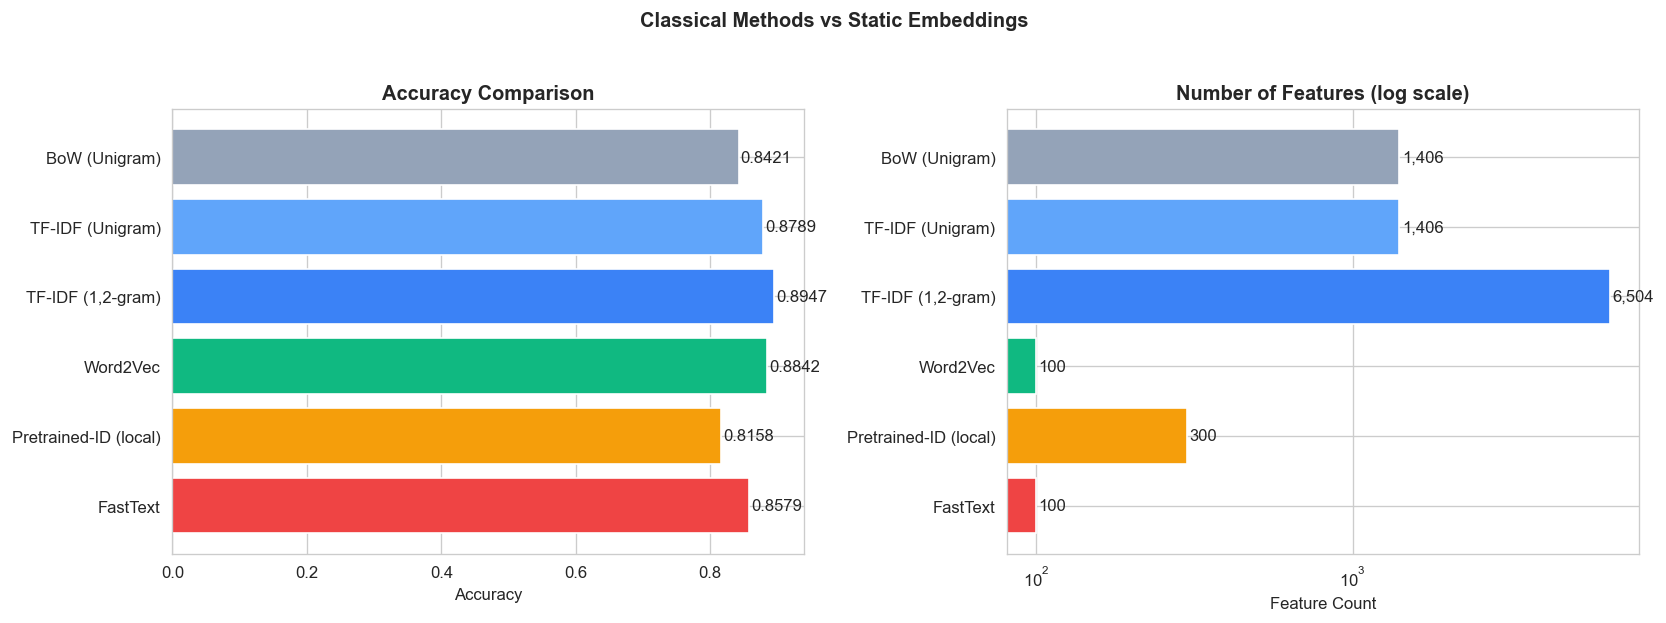

In [45]:
# Visualisasi akurasi dan jumlah fitur
methods = list(all_results.keys())
accs = [all_results[m]['accuracy'] for m in methods]
dims = [all_results[m]['n_features'] for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#94a3b8', '#60a5fa', '#3b82f6', '#10b981', '#f59e0b', '#ef4444'][:len(methods)]

bars1 = ax1.barh(methods, accs, color=colors)
for b, v in zip(bars1, accs):
    ax1.text(v + 0.003, b.get_y() + b.get_height() / 2, f'{v:.4f}', va='center')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_xlabel('Accuracy')
ax1.invert_yaxis()

bars2 = ax2.barh(methods, dims, color=colors)
for b, v in zip(bars2, dims):
    ax2.text(v * 1.02, b.get_y() + b.get_height() / 2, f'{v:,}', va='center')
ax2.set_xscale('log')
ax2.set_title('Number of Features (log scale)', fontweight='bold')
ax2.set_xlabel('Feature Count')
ax2.invert_yaxis()

plt.suptitle('Classical Methods vs Static Embeddings', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Perbandingan 4: t-SNE visualization
vis_words = [
    'error', 'gangguan', 'lambat', 'mudah', 'bagus',
    'bayar', 'pembayaran', 'refund', 'tiket', 'kereta',
    'jadwal', 'batal', 'server', 'aplikasi'
]

common_words = []
for w in vis_words:
    q = map_query_for_pretrained(w)
    if (w in w2v_model.wv) and (q in comparison_pretrained_model) and (w in ft_model.wv):
        common_words.append(w)

print(f'Jumlah kata untuk visualisasi: {len(common_words)}')
print('Kata:', common_words)

Jumlah kata untuk visualisasi: 11
Kata: ['error', 'lambat', 'mudah', 'bagus', 'bayar', 'pembayaran', 'tiket', 'kereta', 'jadwal', 'server', 'aplikasi']


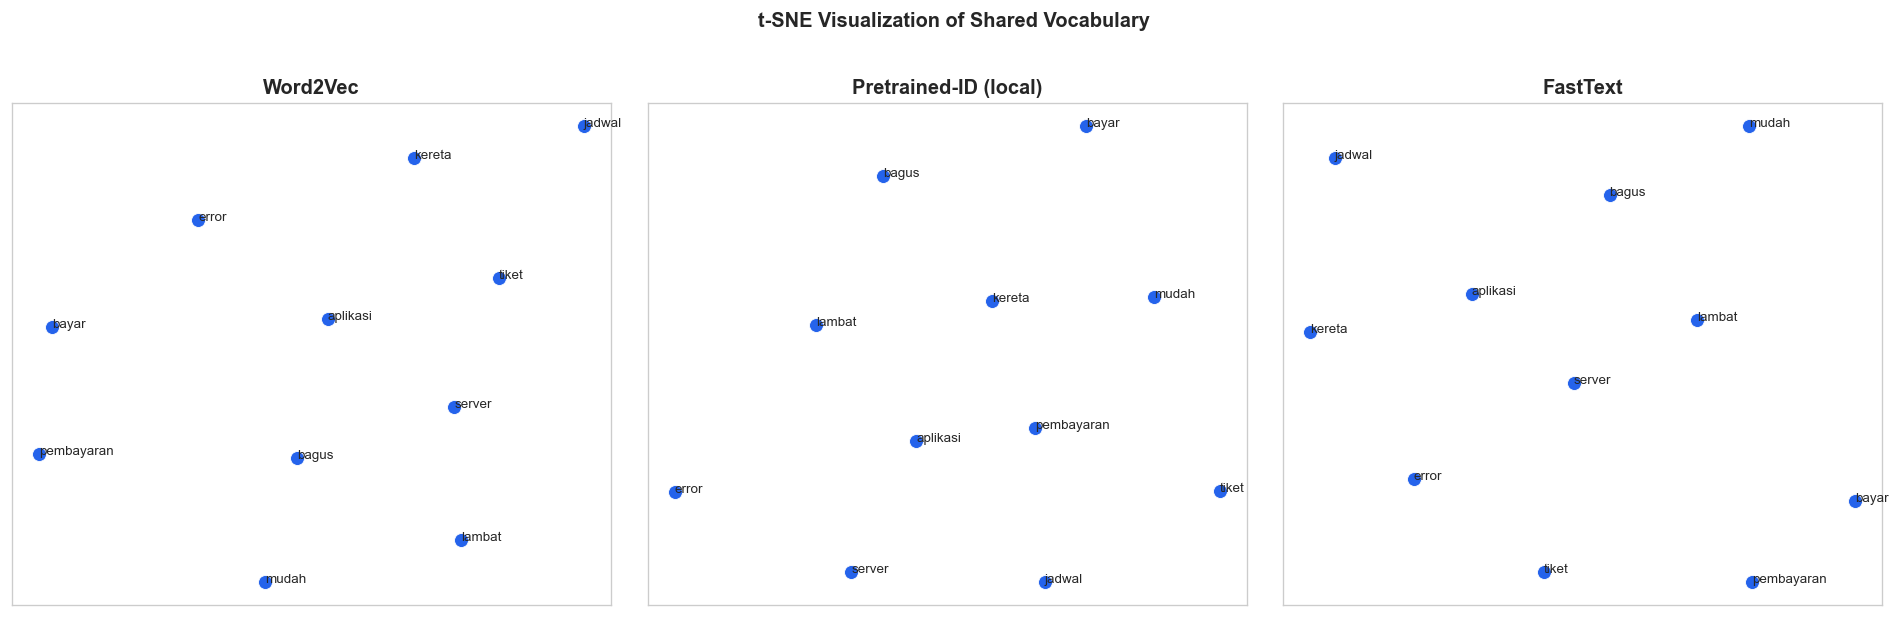

In [47]:
# Plot t-SNE tiga model jika kata cukup
def plot_tsne(model, words, title, ax, mapper=None):
    mapped_words = [mapper(w) if mapper else w for w in words]
    vectors = np.array([model[w] for w in mapped_words])

    if vectors.shape[1] > 20 and vectors.shape[0] > 20:
        pca = PCA(n_components=min(20, vectors.shape[0], vectors.shape[1]), random_state=42)
        vectors = pca.fit_transform(vectors)

    tsne = TSNE(n_components=2, random_state=42, perplexity=max(2, min(8, len(words) - 1)))
    coords = tsne.fit_transform(vectors)

    ax.scatter(coords[:, 0], coords[:, 1], c='#2563eb', s=70, edgecolors='white', linewidths=0.5)
    for i, w in enumerate(words):
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

if len(common_words) >= 5:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plot_tsne(w2v_model.wv, common_words, 'Word2Vec', axes[0])
    plot_tsne(
        comparison_pretrained_model,
        common_words,
        comparison_pretrained_name,
        axes[1],
        mapper=map_query_for_pretrained
    )
    plot_tsne(ft_model.wv, common_words, 'FastText', axes[2])
    plt.suptitle('t-SNE Visualization of Shared Vocabulary', y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Kata overlap antar model terlalu sedikit untuk t-SNE yang stabil.')

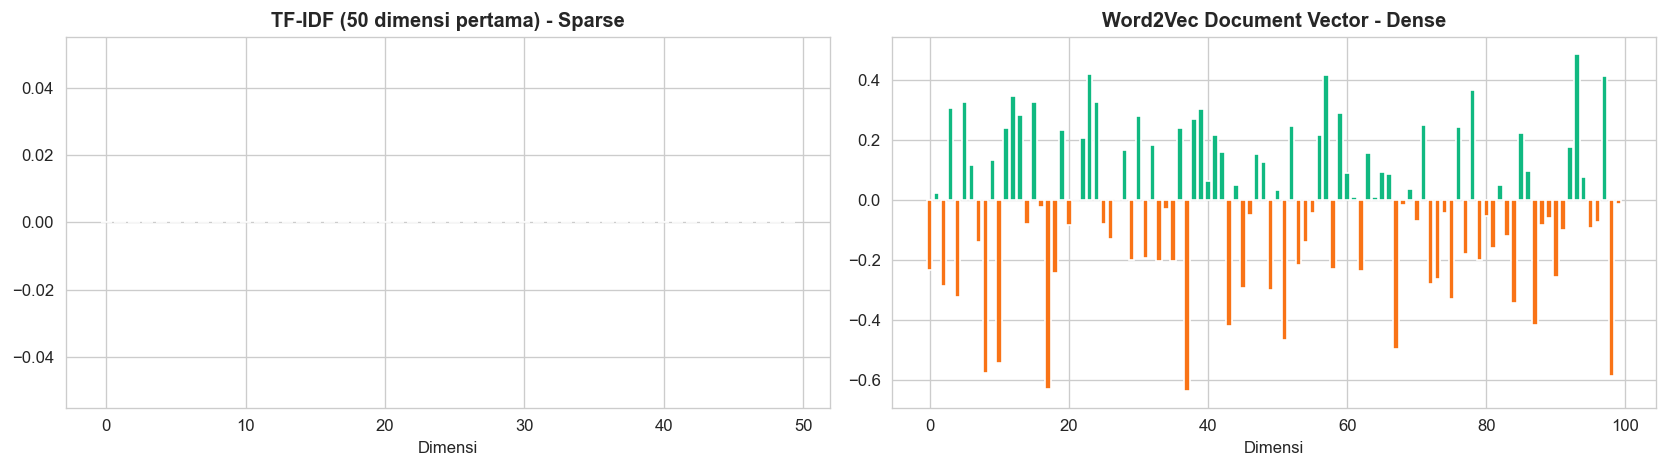

TF-IDF dimensi : 1,406 | sparsity: 99.86%
Word2Vec dimensi: 100 | sparsity: 0.00%


In [48]:
# Perbandingan 5: Sparse vs Dense
sample_idx = 0
tfidf_vec = configs['TF-IDF (Unigram)']['X_train'][sample_idx].toarray().flatten()
w2v_vec = X_train_w2v[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tfidf_50 = tfidf_vec[:50]
axes[0].bar(range(50), tfidf_50, color=['#3b82f6' if v > 0 else '#e5e7eb' for v in tfidf_50])
axes[0].set_title('TF-IDF (50 dimensi pertama) - Sparse', fontweight='bold')
axes[0].set_xlabel('Dimensi')

axes[1].bar(range(len(w2v_vec)), w2v_vec, color=['#10b981' if v >= 0 else '#f97316' for v in w2v_vec])
axes[1].set_title('Word2Vec Document Vector - Dense', fontweight='bold')
axes[1].set_xlabel('Dimensi')

plt.tight_layout()
plt.show()

sparsity_doc = 1 - (np.count_nonzero(tfidf_vec) / len(tfidf_vec))
print(f'TF-IDF dimensi : {len(tfidf_vec):,} | sparsity: {sparsity_doc * 100:.2f}%')
print(f'Word2Vec dimensi: {len(w2v_vec)} | sparsity: 0.00%')

In [49]:
# Perbandingan 6: OOV coverage statistik
oov_test_words = ['errorrr', 'lemoooot', 'pembayaraaan', 'cancelin', 'baguusss']

stats = {'Word2Vec': 0, 'GloVe': 0, 'FastText': 0}

print(f"{'Kata':<18} {'Word2Vec':<12} {'GloVe':<12} {'FastText':<12}")
print('-' * 60)
for w in oov_test_words:
    w2v_ok = w in w2v_model.wv
    glove_ok = w in glove_model
    try:
        _ = ft_model.wv[w]
        ft_ok = True
    except KeyError:
        ft_ok = False

    stats['Word2Vec'] += int(w2v_ok)
    stats['GloVe'] += int(glove_ok)
    stats['FastText'] += int(ft_ok)

    print(f"{w:<18} {('OK' if w2v_ok else 'OOV'):<12} {('OK' if glove_ok else 'OOV'):<12} {('OK' if ft_ok else 'OOV'):<12}")

n = len(oov_test_words)
print('-' * 60)
print(f"Coverage Word2Vec: {stats['Word2Vec']}/{n}")
print(f"Coverage GloVe   : {stats['GloVe']}/{n}")
print(f"Coverage FastText: {stats['FastText']}/{n}")

Kata               Word2Vec     GloVe        FastText    
------------------------------------------------------------
errorrr            OOV          OOV          OK          
lemoooot           OOV          OOV          OK          
pembayaraaan       OOV          OOV          OK          
cancelin           OOV          OOV          OK          
baguusss           OOV          OOV          OK          
------------------------------------------------------------
Coverage Word2Vec: 0/5
Coverage GloVe   : 0/5
Coverage FastText: 5/5


---
## BAGIAN 4 - Step Lanjutan (Advanced Improvement)

Bagian ini menambahkan peningkatan lanjutan:
1. Auto-download pre-trained Indonesian vectors (opsional, ukuran besar).
2. Mini grid search untuk Word2Vec dan FastText.
3. Ringkasan hasil final siap pakai untuk laporan.

In [50]:
# [Opsional] Auto-download pre-trained Indonesian vectors (FastText CC-ID)
import os
import urllib.request

DOWNLOAD_INDO_VECTORS = False  # ubah ke True jika ingin download otomatis
INDO_VEC_URL = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz'
INDO_VEC_PATH = 'cc.id.300.vec.gz'

if DOWNLOAD_INDO_VECTORS:
    if os.path.exists(INDO_VEC_PATH):
        print(f'File sudah ada: {INDO_VEC_PATH}')
    else:
        print('Mulai download pre-trained Indonesian vectors...')
        print('Catatan: ukuran file sangat besar (>1GB), butuh waktu lama.')
        urllib.request.urlretrieve(INDO_VEC_URL, INDO_VEC_PATH)
        print(f'Selesai download: {INDO_VEC_PATH}')
else:
    print('Download otomatis dinonaktifkan (DOWNLOAD_INDO_VECTORS=False).')
    print('Jika ingin aktifkan, ubah flag jadi True lalu jalankan ulang cell ini.')

Download otomatis dinonaktifkan (DOWNLOAD_INDO_VECTORS=False).
Jika ingin aktifkan, ubah flag jadi True lalu jalankan ulang cell ini.


In [51]:
# Mini grid search: Word2Vec (ringan, untuk corpus kecil-menengah)
from itertools import product
from IPython.display import display

def evaluate_doc_embedding_features(X_tr, X_te, y_tr, y_te):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    return accuracy_score(y_te, pred)

def build_doc_vectors(sentences, keyed_vectors, dim):
    vecs = []
    for s in sentences:
        vals = [keyed_vectors[w] for w in s if w in keyed_vectors]
        vecs.append(np.mean(vals, axis=0) if vals else np.zeros(dim))
    return np.array(vecs)

w2v_grid = {
    'window': [3, 4, 5],
    'min_count': [2, 3],
    'epochs': [40, 60],
}

w2v_results = []
for window, min_count, epochs in product(w2v_grid['window'], w2v_grid['min_count'], w2v_grid['epochs']):
    model = Word2Vec(
        sentences=train_sentences,
        vector_size=100,
        window=window,
        min_count=min_count,
        sg=1,
        negative=12,
        sample=1e-3,
        epochs=epochs,
        workers=4,
        seed=42,
    )
    Xtr = build_doc_vectors(train_sentences, model.wv, 100)
    Xte = build_doc_vectors(test_sentences, model.wv, 100)
    acc = evaluate_doc_embedding_features(Xtr, Xte, train_labels, test_labels)
    w2v_results.append({
        'window': window,
        'min_count': min_count,
        'epochs': epochs,
        'accuracy': acc,
    })

w2v_tuning_df = pd.DataFrame(w2v_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
best_w2v_cfg = w2v_tuning_df.iloc[0].to_dict()

print('Top-5 hasil tuning Word2Vec:')
display(w2v_tuning_df.head(5))
print('Best config Word2Vec:', best_w2v_cfg)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Top-5 hasil tuning Word2Vec:


,window,min_count,epochs,accuracy
0,4,3,60,0.884211
1,4,2,60,0.873684
2,5,2,60,0.873684
3,5,3,60,0.873684
4,3,3,60,0.868421


Best config Word2Vec: {'window': 4.0, 'min_count': 3.0, 'epochs': 60.0, 'accuracy': 0.8842105263157894}


In [52]:
# Mini grid search: FastText
ft_grid = {
    'window': [3, 4, 5],
    'min_count': [2, 3],
    'epochs': [35, 50],
    'min_n': [3],
    'max_n': [6],
}

ft_results = []
for window, min_count, epochs in product(ft_grid['window'], ft_grid['min_count'], ft_grid['epochs']):
    model = FastText(
        sentences=train_sentences,
        vector_size=100,
        window=window,
        min_count=min_count,
        sg=1,
        negative=12,
        sample=1e-3,
        min_n=3,
        max_n=6,
        epochs=epochs,
        workers=4,
        seed=42,
    )
    Xtr = build_doc_vectors(train_sentences, model.wv, 100)
    Xte = build_doc_vectors(test_sentences, model.wv, 100)
    acc = evaluate_doc_embedding_features(Xtr, Xte, train_labels, test_labels)
    ft_results.append({
        'window': window,
        'min_count': min_count,
        'epochs': epochs,
        'accuracy': acc,
    })

ft_tuning_df = pd.DataFrame(ft_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
best_ft_cfg = ft_tuning_df.iloc[0].to_dict()

print('Top-5 hasil tuning FastText:')
display(ft_tuning_df.head(5))
print('Best config FastText:', best_ft_cfg)

Top-5 hasil tuning FastText:


,window,min_count,epochs,accuracy
0,5,2,50,0.873684
1,5,3,50,0.873684
2,3,3,50,0.863158
3,4,2,50,0.857895
4,4,3,50,0.857895


Best config FastText: {'window': 5.0, 'min_count': 2.0, 'epochs': 50.0, 'accuracy': 0.8736842105263158}


---
## Ringkasan Kesimpulan Akhir
Berikut adalah tabel interpretasi untuk laporan:

| Metode / Embedding | Kelebihan | Kekurangan | Kapan Digunakan |
|---|---|---|---|
| **Classical (BoW / TF-IDF)** | Sederhana, sangat cepat, baseline yang kuat. | Sparse, dimensi besar, tidak menangkap semantik kata (orthogonal). | Dataset kecil, saat memori/komputasi terbatas, text-matching sederhana. |
| **Word2Vec (Train from scratch)** | Menangkap hubungan semantik spesifik domain, ukuran model kecil. | Masalah Out-Of-Vocabulary (OOV), butuh corpus cukup agar representasinya bagus. | Dataset cukup besar, ada domain spesifik (misal slang, istilah teknis). |
| **GloVe / FastText (Pre-trained)** | Pengetahuan semantik bahasa sangat luas, representasi kaya sejak awal. | Ukuran model besar, bisa lambat dimuat ke RAM. | Dataset umum, sentimen analisis standar, corpus training kecil. |
| **FastText (Subword)** | Handal menangani kata baru (OOV), typo, atau imbuhan. | Waktu training dan ukuran lebih berat dari Word2Vec biasa. | Data banyak typo, kata gaul, variasi slang, bahasa agglutinative (seperti Indonesia). |

**Kesimpulan Praktis:**
- Jika data banyak slang/typo $\rightarrow$ **FastText** sangat disarankan.
- Jika data terbatas tapi domain umum $\rightarrow$ **Pre-trained embedding** (load parsial untuk efisiensi).
- Jika butuh komputasi super ringan & hasil lumayan $\rightarrow$ **TF-IDF + N-gram**.
